In [4]:
%reload_ext

UsageError: Missing module name.


# Refinement
Fonction qui va permettre de refine le topolical graphe initial, avec marge d'erreur de 2px

In [ ]:
from skimage import io
from meta import ROOT_DIR
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from typing import List, Optional

from bez.bezier import fit_bezier, interpolate_bezier
from bez.topo_graph import visualize_subgraph, extract_topology_from_skeleton, image_to_skeleton

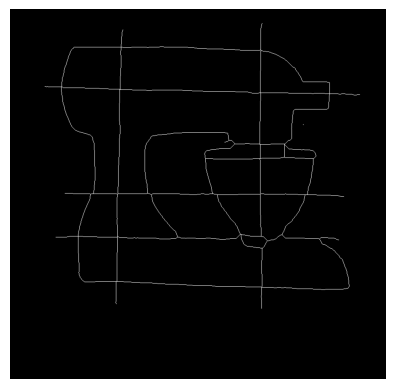

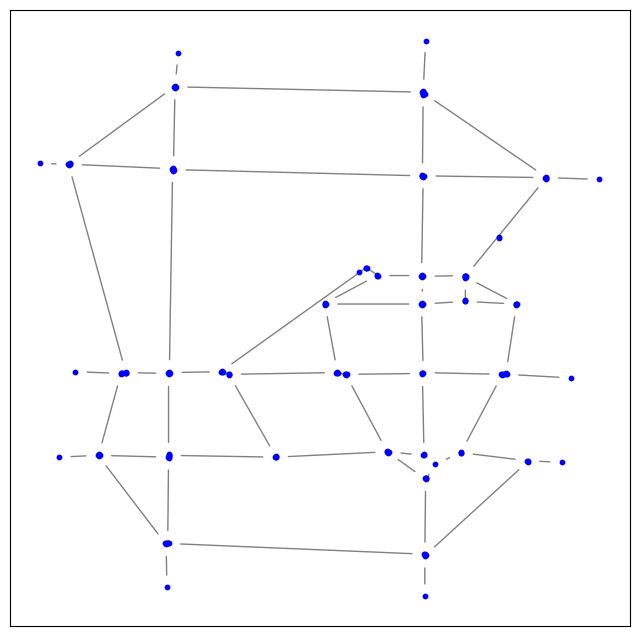

In [ ]:
# Skeleton extraction
img = io.imread(ROOT_DIR /"data/original_paper/figure_2/input.png")

skeletone, thikness = image_to_skeleton(img)
plt.imshow(skeletone, cmap="gray")
plt.axis("off")
plt.show()

topo_graph = extract_topology_from_skeleton(skeletone)

visualize_subgraph(topo_graph, full_graph=True)


In [7]:
print(topo_graph)

print("\n=== Nœuds et attributs ===")
for node, attrs in topo_graph.nodes(data=True):
    print(f"  Nœud {node} : {attrs}")

print("\n=== Arêtes et attributs ===")
for u, v, key, attrs in topo_graph.edges(keys=True, data=True):
    print(f"  Arête {u} <-> {v} (clé {key}) : {attrs}")

print("\n=== Degrés des nœuds ===")
for node, degree in topo_graph.degree():
    print(f"  Nœud {node} : degré {degree}")

MultiGraph with 177 nodes and 285 edges

=== Nœuds et attributs ===
  Nœud (31, 552) : {}
  Nœud (88, 549) : {}
  Nœud (45, 247) : {}
  Nœud (82, 243) : {}
  Nœud (83, 242) : {}
  Nœud (83, 243) : {}
  Nœud (83, 244) : {}
  Nœud (89, 548) : {}
  Nœud (169, 113) : {}
  Nœud (84, 243) : {}
  Nœud (174, 241) : {}
  Nœud (89, 549) : {}
  Nœud (90, 550) : {}
  Nœud (91, 549) : {}
  Nœud (91, 550) : {}
  Nœud (91, 551) : {}
  Nœud (92, 549) : {}
  Nœud (184, 700) : {}
  Nœud (182, 548) : {}
  Nœud (169, 76) : {}
  Nœud (170, 111) : {}
  Nœud (170, 112) : {}
  Nœud (170, 113) : {}
  Nœud (170, 114) : {}
  Nœud (171, 112) : {}
  Nœud (175, 239) : {}
  Nœud (403, 182) : {}
  Nœud (175, 240) : {}
  Nœud (175, 241) : {}
  Nœud (176, 240) : {}
  Nœud (176, 241) : {}
  Nœud (176, 242) : {}
  Nœud (177, 240) : {}
  Nœud (183, 547) : {}
  Nœud (403, 236) : {}
  Nœud (183, 548) : {}
  Nœud (183, 549) : {}
  Nœud (184, 549) : {}
  Nœud (183, 550) : {}
  Nœud (185, 699) : {}
  Nœud (294, 547) : {}
  Nœu

In [3]:
def fit_bezier(pixel_c : np.array):
    return param, error


def devide(pixel_c: np.ndarray, precision: float = 2.0) -> Optional[int]:
    _, e = fit_bezier(pixel_c)
    if e <= precision:
        return None

    N = len(pixel_c)

    _, e1 = fit_bezier(pixel_c[:N // 3])
    _, e2 = fit_bezier(pixel_c[N // 3:])
    _, e3 = fit_bezier(pixel_c[:2 * N // 3])
    _, e4 = fit_bezier(pixel_c[2 * N // 3:])

    if e1 + e2 < e3 + e4:
        first = devide(pixel_c[:N//3])
        second = devide(pixel_c[N//3:])
        idx = np.array([N//3])

        if first is None:
            first = np.array([])
        if second is None:
            second = np.array([])
        else:
            second = second + idx  # ajout de idx à chaque élément

        return np.concatenate([first, idx, second])
    
    else : 
        first = devide(pixel_c[:2*N//3])
        second = devide(pixel_c[2*N//3:])
        idx = np.array([2*N//3])

        if first is None:
            first = np.array([])
        if second is None:
            second = np.array([])
        else:
            second = second + idx  # ajout de idx à chaque élément

        return np.concatenate([first, idx, second])



def refine(topo_g: nx.MultiDiGraph, topo_c: List[np.ndarray], precision: float = 2.0):
    new_edges = []
    new_curves = []

    next_node_id = max(topo_g.nodes) + 1 if topo_g.nodes else 0

    for u, v, key in topo_g.edges(keys=True):
        curve = topo_c[key]
        indices = devide(curve, precision)

        if indices is None or len(indices) == 0:
            # Rien à changer
            new_edges.append((u, v))
            new_curves.append(curve)
            continue

        # Supprimer l’arête originale
        topo_g.remove_edge(u, v, key=key)

        # Créer les nouveaux points d'interpolation
        indices = list(indices.astype(int))
        cuts = [0] + indices + [len(curve)]
        points = [curve[cuts[i]:cuts[i+1]] for i in range(len(cuts) - 1)]

        # Ajouter les nouveaux nœuds et arêtes
        nodes = [u] + [next_node_id + i for i in range(len(points) - 2)] + [v]
        for i in range(len(points)):
            if i < len(points) - 1:
                new_edges.append((nodes[i], nodes[i+1]))
                new_curves.append(points[i])
        next_node_id += len(points) - 2

    # Remplacer topo_c par les courbes mises à jour
    topo_g.clear_edges()
    for i, (a, b) in enumerate(new_edges):
        topo_g.add_edge(a, b, key=i)
    topo_c.clear()
    topo_c.extend(new_curves)


